**You are tasked with developing a predictive model to estimate the median value of owner-occupied homes (MEDV) in various neighborhoods of Boston. To achieve this, you will use the Boston Housing dataset, which contains various features describing different aspects of the neighborhoods.**

Dataset Description:

The Boston Housing dataset includes the following features:

CRIM: Per capita crime rate by town.

ZN: Proportion of residential land zoned for large lots.

INDUS: Proportion of non-retail business acres per town.

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise).

NOX: Nitrogen oxide concentration (parts per 10 million).

RM: Average number of rooms per dwelling.

AGE: Proportion of owner-occupied units built before 1940.

DIS: Weighted distance to employment centers.

RAD: Index of accessibility to radial highways.

TAX: Property tax rate.

PTRATIO: Pupil-teacher ratio.

B: Proportion of residents of African American descent.

LSTAT: Percentage of lower status population.

**Objective:**

Your objective is to build a simple linear regression model that predicts the median value of homes (MEDV) based on a single feature, specifically the average number of rooms per dwelling (RM). The goal is to create a model that accurately estimates the MEDV using the RM feature.

**Tasks:**

Load the Boston Housing dataset from the provided source.

Preprocess the dataset by selecting the RM feature as the independent variable (X) and the MEDV as the dependent variable (y).

Split the dataset into training and testing sets (e.g., 80% for training and 20% for testing) to evaluate the model's performance.

Develop a simple linear regression model using the training data, where you predict MEDV based on RM.

Evaluate the model's performance on the testing data using various metrics such as RMSE, MAE, MAPE, R², and Adjusted R².

Visualize the model's predictions by plotting the regression line against the actual data points.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path='/content/drive/MyDrive/Data set/Boston_Housing.csv'
df=pd.read_csv(path,index_col=0)
df.head(3)

Mounted at /content/drive


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


In [ ]:
df.shape

(506, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 59.3 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().round(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0
mean,3.6,11.4,11.1,0.1,0.6,6.3,68.6,3.8,9.5,408.2,18.5,356.7,12.7,22.5
std,8.6,23.3,6.9,0.3,0.1,0.7,28.1,2.1,8.7,168.5,2.2,91.3,7.1,9.2
min,0.0,0.0,0.5,0.0,0.4,3.6,2.9,1.1,1.0,187.0,12.6,0.3,1.7,5.0
25%,0.1,0.0,5.2,0.0,0.4,5.9,45.0,2.1,4.0,279.0,17.4,375.4,7.0,17.0
50%,0.3,0.0,9.7,0.0,0.5,6.2,77.5,3.2,5.0,330.0,19.0,391.4,11.4,21.2
75%,3.7,12.5,18.1,0.0,0.6,6.6,94.1,5.2,24.0,666.0,20.2,396.2,17.0,25.0
max,89.0,100.0,27.7,1.0,0.9,8.8,100.0,12.1,24.0,711.0,22.0,396.9,38.0,50.0


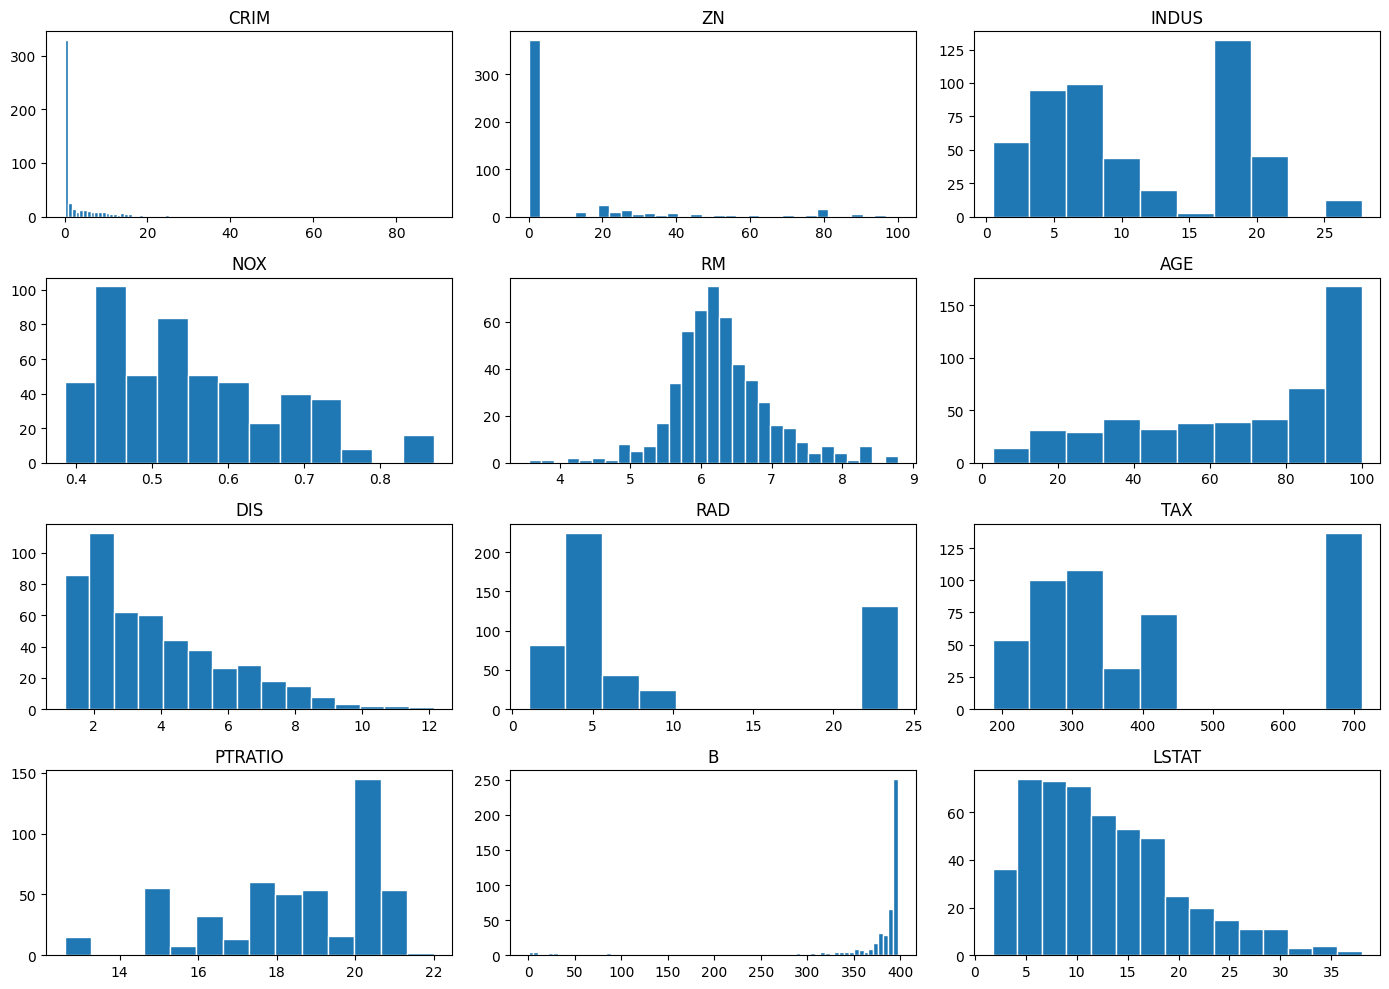

In [ ]:
columns = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM','AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO','B','LSTAT']
#2. Generate the histogram grid
df[columns].hist(figsize=(14, 10), bins='auto', grid=False, edgecolor='white')
# 3. Adjust spacing and render
plt.tight_layout()
plt.show()

A **Kernel Density Estimate (KDE)** is a smooth, continuous curve used to visualize the distribution of a dataset by placing a small bell-shaped curve over every single data point and adding them together.

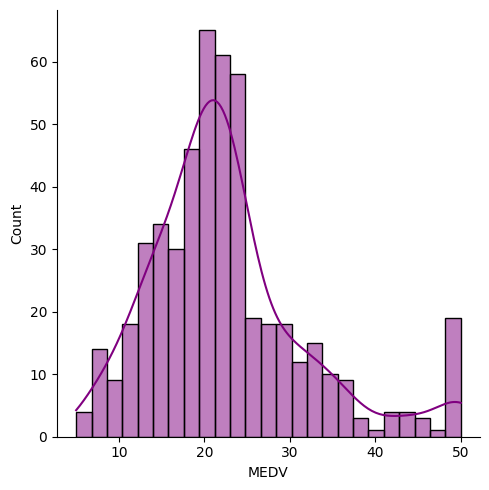

In [ ]:
sns.displot(df['MEDV'], bins=25, kde=True, color='purple')   #Kernel Density Estimate (KDE)

Majority of Houses has values beteern 10000 dollers to 30000 dollers

In [ ]:
df.value_counts('CHAS',normalize=True).round(2)

,proportion
CHAS,
0.0,0.93
1.0,0.07


Only 7% houses neighborhood directly touches the banks of the Charles River.

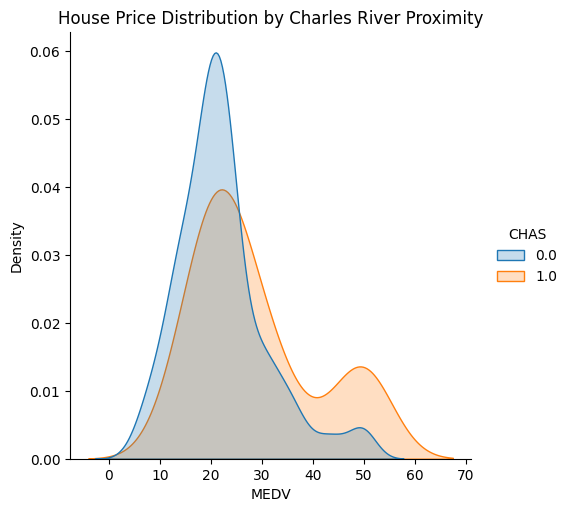

In [ ]:
# Plot side-by-side or overlapping KDE curves grouped by CHAS
sns.displot(
    data=df,
    x='MEDV',
    hue='CHAS',         # Splits and colors the curves by river proximity
    kind='kde',         # Switches the plot type from histogram to smooth KDE
    fill=True,          # Adds a transparent color fill under the curves
    common_norm=False   # Scales each group independently for fair comparison
)

plt.title('House Price Distribution by Charles River Proximity')
plt.show()

**Conclusion:**

houses bordering the Charles River (CHAS = 1.0, orange) are generally **more expensive and have a higher concentration of luxury values** than houses that do not (CHAS = 0.0, blue)

**Blue Curve (CHAS = 0.0):** This is mostly a single-peaked (unimodal) distribution tightly gathered around dollers 20000. The vast majority of standard homes are concentrated in this mid-to-low range.

**Orange Curve (CHAS = 1.0):** This is a two-peaked (bimodal) distribution. It shows that riverfront homes are split into two distinct categories: standard-priced homes around dolers 23000 and premium/luxury tier homes around 50000.

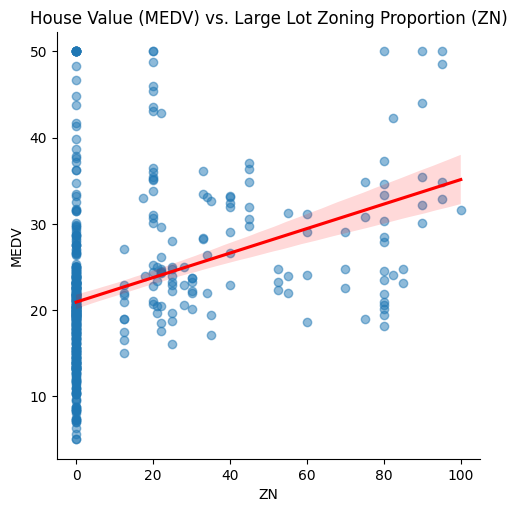

In [ ]:
sns.lmplot(data=df, x='ZN', y='MEDV', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('House Value (MEDV) vs. Large Lot Zoning Proportion (ZN)')
plt.show()

This plot indicates a **positive linear relationship** between the proportion of large-lot residential zoning (ZN) and the median house values (MEDV).

**Lets find out the correlation of all independant variables with 'MEDV'**

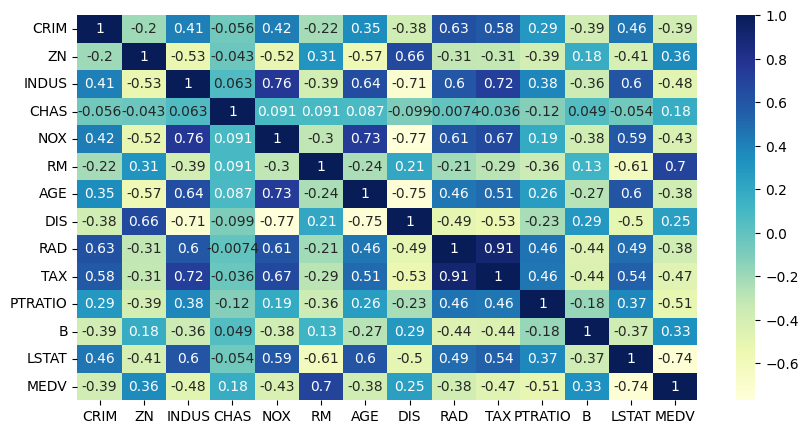

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True,cmap="YlGnBu")
plt.show()

**Remove Weak Predictors:**

**CHAS (0.18), DIS(0.25) vs. MEDV**: This is weak correlation thus this should be redundant

**Resolve Multicorrelation:**

RAD vs TAX (Correlation: 0.91)

RAD correlation with MEDV = -0.38 TAX correlation with MEDV = -0.47 (Stronger)

Thus Keep TAX. Remove RAD.


INDUS vs NOX (0.76) -> Keep INDUS (-0.48 with MEDV) & Remove NOX (-0.43 with MEDV)

INDUS vs TAX (0.72) -> Keep TAX (-0.47 with MEDV)& Remove INDUS (-0.48 with MEDV is nearly identical, but INDUS triggers multiple other >0.7 issues with NOX and LSTAT). Thus Remove INDUS and Keep Tax


AGE vs NOX (0.73)-> NOX is already removed.


LSTAT vs INDUS (0.60), LSTAT vs NOX (0.59), LSTAT vs AGE (0.60) -> NAX & INDUS is already removed

Target Power Check: LSTAT has an incredible -0.74 correlation with MEDV.

**Final Feture List: ['CRIM', 'ZN', 'RM', 'TAX', 'PTRATIO', 'B', 'LSTAT','AGE']**

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Define your input X
X = df[["CRIM", "ZN", "RM", "TAX", "PTRATIO", "B","LSTAT","AGE"]]

# 2. Add a constant column (intercept) - Crucial for accurate VIF calculation
X_with_const = X.copy()
X_with_const["constant"] = 1

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i) for i in range(X.shape[1])
]

# 4. Display the results sorted by highest VIF
print(vif_data.sort_values(by="VIF", ascending=False))

   Feature       VIF
6    LSTAT  2.892066
7      AGE  2.265766
3      TAX  2.209193
2       RM  1.810935
1       ZN  1.691718
0     CRIM  1.621034
4  PTRATIO  1.481106
5        B  1.327801


**NO VIF score is above 5 this all Features is selected for model creation.**

In [ ]:
X=df[["CRIM","ZN","RM","TAX","PTRATIO","B","LSTAT","AGE"]]
Y=df['MEDV']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=1)
# Shape of training data
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(404, 8)
(404,)
(102, 8)
(102,)


In [ ]:
from sklearn.linear_model import LinearRegression
#Create liner regression model
model=LinearRegression()
# Train the model
model.fit(x_train,y_train)
# Make predictions
y_pred=model.predict(x_test)

# Create comparison table
result=x_test.copy()
result['Actual MEDV']=y_test
result['Predicted MEDV']=y_pred.round(1)
result.head(3)


,CRIM,ZN,RM,TAX,PTRATIO,B,LSTAT,AGE,Actual MEDV,Predicted MEDV
307,0.04932,33.0,6.849,222.0,18.4,396.90,7.53,70.3,28.2,28.5
343,0.02543,55.0,6.696,370.0,17.6,396.90,7.18,56.4,23.9,28.7
47,0.22927,0.0,6.030,233.0,17.9,392.74,18.80,85.5,16.6,19.3


In [ ]:
result['Difference']=result['Actual MEDV']-result['Predicted MEDV']
result.head(3)


,CRIM,ZN,RM,TAX,PTRATIO,B,LSTAT,AGE,Actual MEDV,Predicted MEDV,Difference
307,0.04932,33.0,6.849,222.0,18.4,396.90,7.53,70.3,28.2,28.5,-0.3
343,0.02543,55.0,6.696,370.0,17.6,396.90,7.18,56.4,23.9,28.7,-4.8
47,0.22927,0.0,6.030,233.0,17.9,392.74,18.80,85.5,16.6,19.3,-2.7


In [ ]:
result['Actual MEDV'].mean().round(2)

np.float64(22.57)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score,mean_absolute_percentage_error

mse= mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)
mape=mean_absolute_percentage_error(y_test,y_pred)*100
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Square Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"R-Squared: {r2:.2f}")

Mean Squared Error: 28.40
Root Mean Square Error: 5.33
Mean Absolute Error: 4.15
Mean Absolute Percentage Error: 20.22%
R-Squared: 0.71


**This model has an average error around 4015 Dollers for median value of owner occupied homes**

This model provides a reasonable baseline prediction but still leaves room for improvement.

RMSE > MAE, it indicates that your dataset contains outliers or specific suburbs where the model made very large prediction errors.

** On average, your model's predictions deviate from the true property price by 20.22%**

 **R-Squared value of 0.71 means that 71% of the variance in the Boston house prices (MEDV) can be explained by your linear regression model's features** ('CRIM', 'ZN', 'RM', 'TAX', 'PTRATIO', 'B', 'LSTAT','AGE').The remaining 29% of the variation is due to unexplained factors, which could include missing features, random noise, or non-linear relationships.

**Lets apply Regularization to find better model**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold

# 1. Prepare your optimized feature set
X_clean = df[["CRIM", "ZN", "RM", "TAX", "PTRATIO", "B", "LSTAT","AGE"]]
Y = df["MEDV"]

# 2. Define a search range of alphas (from 0.0001 to 1.0 on a log scale)
alphas_to_test = np.logspace(-4, 0, 100)

# 3. Setup Cross-Validation (e.g., 5-fold cross-validation repeated 3 times)
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# 4. Initialize and fit LassoCV
lasso_cv = LassoCV(alphas=alphas_to_test, cv=cv, n_jobs=-1, random_state=42)
lasso_cv.fit(X_clean, Y)

# 5. Output the mathematically ideal alpha
print(f"🥇 The mathematically ideal Alpha value is: {lasso_cv.alpha_:.4f}")


🥇 The mathematically ideal Alpha value is: 0.0351


In [ ]:
from sklearn.linear_model import Lasso,Ridge
lasso= Lasso(alpha=0.0201)

# Train the model
lasso.fit(x_train, y_train)

# Evaluate the model
y_pred_lasso = lasso.predict(x_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lesso=np.sqrt(mse_lasso)
mae_lasso=mean_absolute_error(y_test,y_pred_lasso)
mape_lasso=mean_absolute_percentage_error(y_test,y_pred_lasso)*100
print(f"Lasso Regression Mean Squared Error: {mse_lasso:.2f}")
print(f"Lasso Regression Root Mean Squared Error: {rmse_lesso:.2f}")
print(f"Lasso Regression Mean Absolute Error: {mae_lasso:.2f}")
print(f"Lasso Regression Mean Absolute Percentage Error: {mape_lasso:.2f}")

Lasso Regression Mean Squared Error: 28.55
Lasso Regression Root Mean Squared Error: 5.34
Lasso Regression Mean Absolute Error: 4.15
Lasso Regression Mean Absolute Percentage Error: 20.21


These metrics show that Linear Regression and Lasso Regression models are performing almost identically, with Linear Regression holding a microscopic, negligible edge in overall accuracy.

As cost function result of Lasso & Linear regression is almost simmilar, indicates that The initial feature selection process using correlation thresholds successfully eliminated severe multicollinearity.

Therefore, the ordinary Linear Regression model with the trimmed feature set is the preferred final choice due to its slightly lower overall error and simpler architecture.

The persistent gap between RMSE (5.33 / 5.34) and MAE (4.15) in both models confirms that your error is being driven by a handful of large outlier data points.

**TO REMOVE THE OUTLIERS**

In [ ]:
import numpy as np
import pandas as pd

# 1. Define your features and target
features = ["CRIM","ZN","RM","TAX","PTRATIO","B","LSTAT","AGE"]
X = df[features].copy()
Y = df["MEDV"].copy()


# 2. Function to cap outliers using IQR (Winsorization)
def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the boundaries
        df_capped[col] = np.where(
            df_capped[col] < lower_bound,
            lower_bound,
            np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col]),
        )
    return df_capped


# 3. Apply the capping function to your features
X_cleaned = cap_outliers_iqr(X, features)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_cleaned,Y,test_size=0.2,random_state=1)
# Shape of training data
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(404, 8)
(404,)
(102, 8)
(102,)


In [ ]:
from sklearn.linear_model import LinearRegression
#Create liner regression model
model=LinearRegression()
# Train the model
model.fit(x_train,y_train)
# Make predictions
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score,mean_absolute_percentage_error

mse= mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred)
mape=mean_absolute_percentage_error(y_test,y_pred)*100
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Square Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"R-Squared: {r2:.2f}")

Mean Squared Error: 31.04
Root Mean Square Error: 5.57
Mean Absolute Error: 4.35
Mean Absolute Percentage Error: 21.50%
R-Squared: 0.69


Completely removing the identified outliers resulted in a noticeable decline in model performance: the R-Squared dropped from 0.71 to 0.69, and the Root Mean Squared Error (RMSE) increased from 5.34 to 5.57.This regression in performance indicates that the extreme data points in the target variable (MEDV) are not artificial errors or noise; rather, they represent genuine, high-leverage real estate market variations that are crucial for anchoring the model's linear trend. Removing them deprived the model of essential variance. **Therefore, the optimal final pipeline must retain these data points using the ordinary Linear Regression model on the streamlined 7-feature set to preserve maximum predictive accuracy**